# Deep-Learning Assisted Eigenmode Retrieval

We attempt to make predictions on subsequent turbulence eigenmodes with the help of deep learning. We use a Fourier Neural Operator, which is well suited to learn nonlinear functions which applies transformations in the fourier domain.

In [36]:
import torch
import torch.nn as nn
import os
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F
from torch.optim import Adam
import matplotlib.pyplot as plt
from LightPipes import *

import fno
from fno import FNO2d, spectral_relative_l2, make_freq_weights

# Begin by loading up the dataset

In [37]:

DATASET_DIR = "datasets/dataset"   # ← root folder containing t_00001/, t_00002/, ...
N_EIGENMODES_FILE = 4              # number of eigenmodes saved per timestep

def load_csv(path):
    return np.loadtxt(path, delimiter=",")

def load_sample(sample_dir, n_eigenmodes=N_EIGENMODES_FILE):
    """Load all eigenmodes and Gaussian fields from a single timestep directory."""
    d = {}
    for k in range(1, n_eigenmodes + 1):
        d[f"eigenmode_{k}_real"] = load_csv(os.path.join(sample_dir, f"eigenmode_{k:03d}_real.csv"))
        d[f"eigenmode_{k}_imag"] = load_csv(os.path.join(sample_dir, f"eigenmode_{k:03d}_imag.csv"))
    d["gaussian_forward_real"]  = load_csv(os.path.join(sample_dir, "gaussian_prop_forward_real.csv"))
    d["gaussian_forward_imag"]  = load_csv(os.path.join(sample_dir, "gaussian_prop_forward_imag.csv"))
    d["gaussian_reversed_real"] = load_csv(os.path.join(sample_dir, "gaussian_prop_reversed_real.csv"))
    d["gaussian_reversed_imag"] = load_csv(os.path.join(sample_dir, "gaussian_prop_reversed_imag.csv"))
    return d

# Discover and sort all timestep subdirectories
sample_dirs = sorted([
    os.path.join(DATASET_DIR, d)
    for d in os.listdir(DATASET_DIR)
    if os.path.isdir(os.path.join(DATASET_DIR, d))
])

print(f"Found {len(sample_dirs)} timestep directories in '{DATASET_DIR}'")

# Load all samples into a list of dicts
samples = []
for i, sd in enumerate(sample_dirs):
    samples.append(load_sample(sd))
    if (i + 1) % 10 == 0 or (i + 1) == len(sample_dirs):
        print(f"  Loaded {i+1}/{len(sample_dirs)} : {os.path.basename(sd)}")

# Stack into arrays shaped (N_samples, H, W) — same layout as the .npz format
keys = list(samples[0].keys())
data = {k: np.stack([s[k] for s in samples], axis=0) for k in keys}

print(f"\nDataset ready.")
print(f"Keys    : {list(data.keys())}")
print(f"Samples : {data['gaussian_forward_real'].shape[0]}")
print(f"Grid    : {data['gaussian_forward_real'].shape[1:]} (H x W)")


Found 1000 timestep directories in 'datasets/dataset'
  Loaded 10/1000 : t_00010
  Loaded 10/1000 : t_00010
  Loaded 20/1000 : t_00020
  Loaded 20/1000 : t_00020
  Loaded 30/1000 : t_00030
  Loaded 30/1000 : t_00030
  Loaded 40/1000 : t_00040
  Loaded 40/1000 : t_00040
  Loaded 50/1000 : t_00050
  Loaded 50/1000 : t_00050
  Loaded 60/1000 : t_00060
  Loaded 60/1000 : t_00060
  Loaded 70/1000 : t_00070
  Loaded 70/1000 : t_00070
  Loaded 80/1000 : t_00080
  Loaded 80/1000 : t_00080
  Loaded 90/1000 : t_00090
  Loaded 90/1000 : t_00090
  Loaded 100/1000 : t_00100
  Loaded 100/1000 : t_00100
  Loaded 110/1000 : t_00110
  Loaded 110/1000 : t_00110
  Loaded 120/1000 : t_00120
  Loaded 120/1000 : t_00120
  Loaded 130/1000 : t_00130
  Loaded 130/1000 : t_00130
  Loaded 140/1000 : t_00140
  Loaded 140/1000 : t_00140
  Loaded 150/1000 : t_00150
  Loaded 150/1000 : t_00150
  Loaded 160/1000 : t_00160
  Loaded 160/1000 : t_00160
  Loaded 170/1000 : t_00170
  Loaded 170/1000 : t_00170
  Loaded 180

Alternatively, load from a pre-converted `.npz` file (much faster — run `convert_dataset_to_npz.py` first).

In [46]:

NPZ_PATH = "datasets/dataset.npz"   # ← path to the pre-converted .npz file

npz = np.load(NPZ_PATH)
data = {k: npz[k] for k in npz.files}

print(f"Loaded dataset from '{NPZ_PATH}'")
print(f"Keys    : {list(data.keys())}")
print(f"Samples : {data['gaussian_forward_real'].shape[0]}")
print(f"Grid    : {data['gaussian_forward_real'].shape[1:]} (H x W)")


Loaded dataset from 'datasets/dataset.npz'
Keys    : ['eigenmode_1_real', 'eigenmode_2_real', 'eigenmode_3_real', 'eigenmode_4_real', 'eigenmode_1_imag', 'eigenmode_2_imag', 'eigenmode_3_imag', 'eigenmode_4_imag', 'gaussian_forward_real', 'gaussian_forward_imag', 'gaussian_reversed_real', 'gaussian_reversed_imag']
Samples : 1000
Grid    : (64, 64) (H x W)


For each time step, we have information about four turbulence eigenmodes, as well as the gaussian mode going forwards and backwards.

The samples in our dataset must be prepared as single-step predictors, meaning that they are input-output pairs of the form $(E_{t}, P_{t+1}) \rightarrow E_{t+1}$

In [ ]:

N_EIGENMODES = 4

def normalize_11(arr: np.ndarray) -> np.ndarray:
    """Min-max normalise arr to the range [-1, +1]."""
    lo, hi = arr.min(), arr.max()
    if hi - lo < 1e-12:          # constant array — avoid division by zero
        return np.zeros_like(arr)
    return 2.0 * (arr - lo) / (hi - lo) - 1.0

def prepare_pairs(data, n_eigenmodes=N_EIGENMODES):
    """
    Build single-step predictor pairs from the dataset.

    For each consecutive pair of timesteps (t, t+1) and each eigenmode k we form:
      - Input  : [eigenmode_k_real_t,        eigenmode_k_imag_t,
                  gaussian_forward_real_t+1,  gaussian_forward_imag_t+1,
                  gaussian_reversed_real_t+1, gaussian_reversed_imag_t+1]  → (H, W, 6)
      - Target : [eigenmode_k_real_{t+1}, eigenmode_k_imag_{t+1}]          → (H, W, 2)

    Samples are interleaved by timestep (outer) then eigenmode (inner), matching
    prepare_pairs_slow, so that a simple train/test slice gives a proper temporal holdout:
      row index = t * n_eigenmodes + (k - 1)

    The Gaussian forward/reversed channels are normalised to [-1, +1].

    Returns
    -------
    X : torch.Tensor  shape ((N-1)*n_eigenmodes, H, W, 6)
    Y : torch.Tensor  shape ((N-1)*n_eigenmodes, H, W, 2)
    """
    N_samples = data["gaussian_forward_real"].shape[0]
    H, W      = data["gaussian_forward_real"].shape[1:]
    N_pairs   = N_samples - 1
    total     = N_pairs * n_eigenmodes

    # Pre-allocate output arrays
    X = np.empty((total, H, W, 6), dtype=np.float32)
    Y = np.empty((total, H, W, 2), dtype=np.float32)

    # Load and normalise Gaussian arrays once — shared across all eigenmodes
    gfwd_real = normalize_11(data["gaussian_forward_real"][1:].astype(np.float32))  # (N-1, H, W)
    gfwd_imag = normalize_11(data["gaussian_forward_imag"][1:].astype(np.float32))
    grev_real = normalize_11(data["gaussian_reversed_real"][1:].astype(np.float32))
    grev_imag = normalize_11(data["gaussian_reversed_imag"][1:].astype(np.float32))

    # Load all eigenmode arrays up front
    em = {}
    for k in range(1, n_eigenmodes + 1):
        em[k] = (data[f"eigenmode_{k}_real"].astype(np.float32),
                 data[f"eigenmode_{k}_imag"].astype(np.float32))

    # Fill in timestep-major order: row = t * n_eigenmodes + (k-1)
    for t in range(N_pairs):
        for k in range(1, n_eigenmodes + 1):
            row = t * n_eigenmodes + (k - 1)
            em_real, em_imag = em[k]

            X[row, ..., 0] = em_real[t]       # eigenmode k at t
            X[row, ..., 1] = em_imag[t]
            X[row, ..., 2] = gfwd_real[t]     # Gaussian forward at t+1  (normalised)
            X[row, ..., 3] = gfwd_imag[t]
            X[row, ..., 4] = grev_real[t]     # Gaussian reversed at t+1 (normalised)
            X[row, ..., 5] = grev_imag[t]

            Y[row, ..., 0] = em_real[t + 1]   # eigenmode k at t+1
            Y[row, ..., 1] = em_imag[t + 1]

        if (t + 1) % 50 == 0 or (t + 1) == N_pairs:
            print(f"  Processed {t+1}/{N_pairs} timestep pairs ...")

    return torch.from_numpy(X), torch.from_numpy(Y)

X, Y = prepare_pairs(data)

print(f"Input  shape : {X.shape}")   # ((N-1)*4, H, W, 6)
print(f"Target shape : {Y.shape}")   # ((N-1)*4, H, W, 2)


Processing eigenmode 1/4 ...
Processing eigenmode 2/4 ...
Processing eigenmode 3/4 ...
Processing eigenmode 4/4 ...
Input  shape : torch.Size([3996, 64, 64, 6])
Target shape : torch.Size([3996, 64, 64, 2])
Processing eigenmode 4/4 ...
Input  shape : torch.Size([3996, 64, 64, 6])
Target shape : torch.Size([3996, 64, 64, 2])


In [47]:

# ── Original (slow) version — kept for reference ──────────────────────────────
# Builds X and Y by appending to Python lists then stacking at the end.
# Equivalent output to prepare_pairs() above, but uses more memory and is slower.

def prepare_pairs_slow(data, n_eigenmodes=N_EIGENMODES):
    """
    Original list-based implementation of prepare_pairs.

    For each consecutive pair of timesteps (t, t+1) and each eigenmode k:
      - Input  : [eigenmode_k_real_t,        eigenmode_k_imag_t,
                  gaussian_forward_real_t+1,  gaussian_forward_imag_t+1,
                  gaussian_reversed_real_t+1, gaussian_reversed_imag_t+1]
      - Target : [eigenmode_k_real_{t+1}, eigenmode_k_imag_{t+1}]
    """
    N_samples = data["gaussian_forward_real"].shape[0]

    X_list = []
    Y_list = []

    for t in range(N_samples - 1):
        gfwd_real = data["gaussian_forward_real"][t + 1].astype(np.float32)
        gfwd_imag = data["gaussian_forward_imag"][t + 1].astype(np.float32)
        grev_real = data["gaussian_reversed_real"][t + 1].astype(np.float32)
        grev_imag = data["gaussian_reversed_imag"][t + 1].astype(np.float32)

        for k in range(1, n_eigenmodes + 1):
            em_real_t  = data[f"eigenmode_{k}_real"][t].astype(np.float32)
            em_imag_t  = data[f"eigenmode_{k}_imag"][t].astype(np.float32)
            em_real_t1 = data[f"eigenmode_{k}_real"][t + 1].astype(np.float32)
            em_imag_t1 = data[f"eigenmode_{k}_imag"][t + 1].astype(np.float32)

            x = np.stack([em_real_t, em_imag_t,
                          gfwd_real, gfwd_imag,
                          grev_real, grev_imag], axis=-1)   # (H, W, 6)
            y = np.stack([em_real_t1, em_imag_t1], axis=-1) # (H, W, 2)

            X_list.append(x)
            Y_list.append(y)

        if (t + 1) % 50 == 0 or (t + 1) == N_samples - 1:
            print(f"  Processed {t+1}/{N_samples - 1} timestep pairs ...")

    X = torch.from_numpy(np.stack(X_list, axis=0))
    Y = torch.from_numpy(np.stack(Y_list, axis=0))
    return X, Y

# Uncomment to use the slow version instead:
X, Y = prepare_pairs_slow(data)
print(f"Input  shape : {X.shape}")
print(f"Target shape : {Y.shape}")


  Processed 50/999 timestep pairs ...
  Processed 100/999 timestep pairs ...
  Processed 150/999 timestep pairs ...
  Processed 200/999 timestep pairs ...
  Processed 250/999 timestep pairs ...
  Processed 300/999 timestep pairs ...
  Processed 350/999 timestep pairs ...
  Processed 400/999 timestep pairs ...
  Processed 450/999 timestep pairs ...
  Processed 500/999 timestep pairs ...
  Processed 550/999 timestep pairs ...
  Processed 600/999 timestep pairs ...
  Processed 650/999 timestep pairs ...
  Processed 700/999 timestep pairs ...
  Processed 750/999 timestep pairs ...
  Processed 800/999 timestep pairs ...
  Processed 850/999 timestep pairs ...
  Processed 500/999 timestep pairs ...
  Processed 550/999 timestep pairs ...
  Processed 600/999 timestep pairs ...
  Processed 650/999 timestep pairs ...
  Processed 700/999 timestep pairs ...
  Processed 750/999 timestep pairs ...
  Processed 800/999 timestep pairs ...
  Processed 850/999 timestep pairs ...
  Processed 900/999 timest

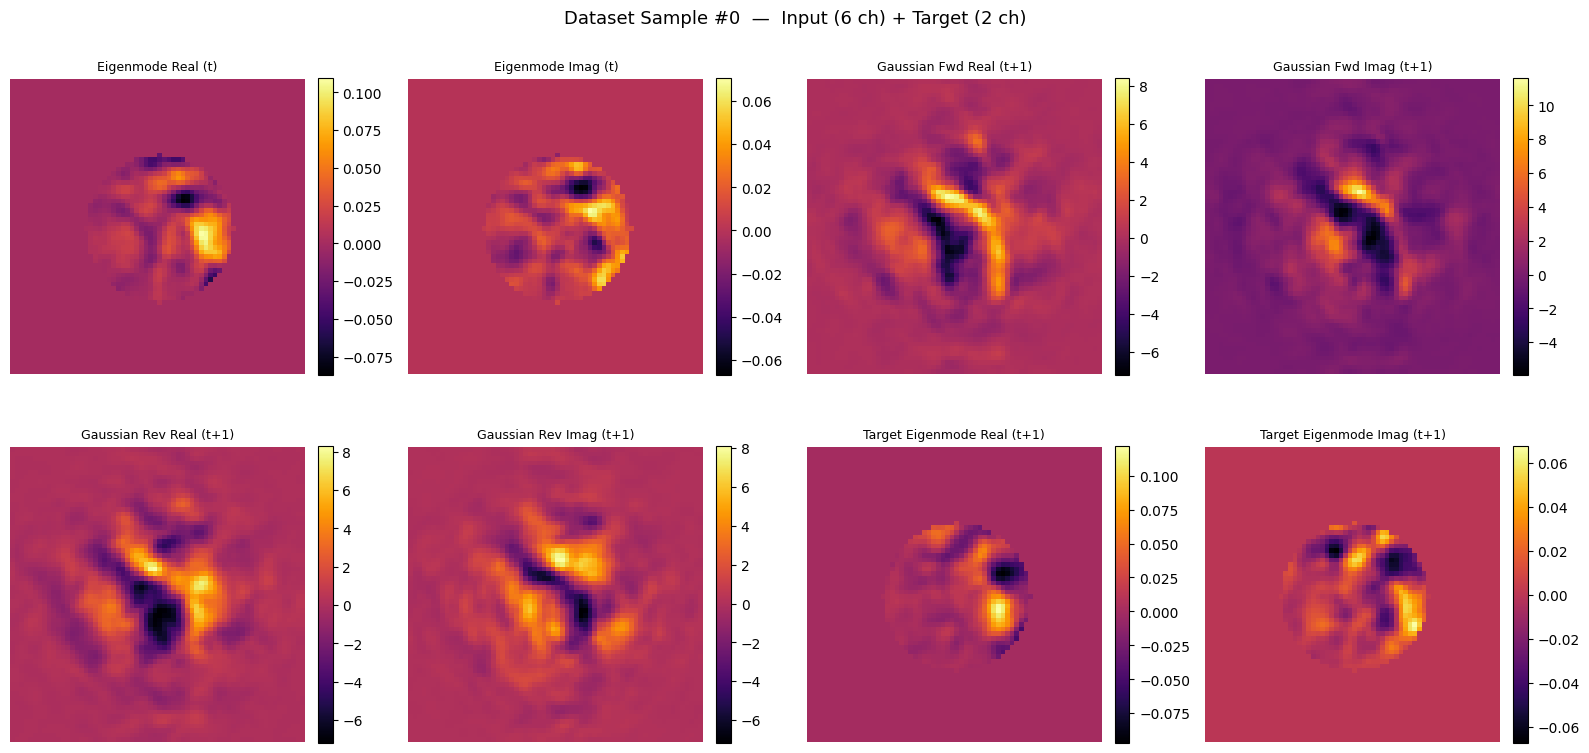

In [39]:
sample_idx = 0   # ← change this to inspect any sample

x_np = X[sample_idx].numpy()   # (H, W, 6)
y_np = Y[sample_idx].numpy()   # (H, W, 2)

channel_labels = [
    "Eigenmode Real (t)",
    "Eigenmode Imag (t)",
    "Gaussian Fwd Real (t+1)",
    "Gaussian Fwd Imag (t+1)",
    "Gaussian Rev Real (t+1)",
    "Gaussian Rev Imag (t+1)",
    "Target Eigenmode Real (t+1)",
    "Target Eigenmode Imag (t+1)",
]

all_data = [x_np[..., c] for c in range(6)] + [y_np[..., c] for c in range(2)]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle(f"Dataset Sample #{sample_idx}  —  Input (6 ch) + Target (2 ch)", fontsize=13)

for ax, arr, lbl in zip(axes.flat, all_data, channel_labels):
    im = ax.imshow(arr, cmap="inferno", aspect="equal")
    ax.set_title(lbl, fontsize=9)
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


Prepare the dataset for training/test

In [48]:
n_train = int(0.80*X.shape[0])
batch_size = 10

x_train =  X[:n_train]
x_test =  X[n_train:]

y_train = Y[:n_train]
y_test = Y[n_train:]

N = x_train.shape[2]

training_set = DataLoader(TensorDataset(x_train, y_train), batch_size=batch_size, shuffle=True)
testing_set = DataLoader(TensorDataset(x_test, y_test), batch_size=batch_size, shuffle=False)

In [49]:
x_batch, y_batch = next(iter(training_set))
print(x_batch.shape)

torch.Size([10, 64, 64, 6])


Instantiate the FNO architecture

In [50]:
epochs = 25

# These control the step-wise updates on the LR

learn_rate = 0.001 # initial LR
step_size = 12 # Number of epochs after which we apply a decay in the learning rate
gamma = 0.5 # factor by whcih we alter the LR

# Parameters we specify the neural network architecture

modes1 = 36 # number of spectral modes along one dimension
modes2 = 36 # number of spectral modes along another dimension
width = 64 # number of neurons in each layer? 
n_layers = 2 # Number of layers
retrain_fno = 99 # This specifies the seed that initializes the FNO parameters

input_chans = 6
output_chans = 2

# Physical parameters 
size = 0.45 #(simulation window)
lensSize = 0.1125 #(size/4)

fno_architecture = {"modes1": modes1, "modes2":modes2, "width":width, "n_layers":n_layers, "retrain_fno":retrain_fno, "input_chans":input_chans, "output_chans":output_chans}


Load up GPU (if not already done so)

In [51]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Is CUDA available? {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")

print(f"Using device: {device} ({torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'})")

Is CUDA available? True
GPU Name: NVIDIA GeForce RTX 5060 Laptop GPU
Using device: cuda (NVIDIA GeForce RTX 5060 Laptop GPU)


To avoid confusion, we apply an aperture on the output predicted channel. 

In [52]:
def torch_circ_aperture(field_batch: torch.Tensor, size: float, lensSize: float) -> torch.Tensor:
    """
    Applies a circular aperture to a batch of complex fields represented
    as real/imaginary channels.

    Parameters
    ----------
    field_batch : torch.Tensor  shape (batch, H, W, C)
                  where C=2 holds [real, imag] channels
    size        : float — physical side length of the window (metres)
    lensSize    : float — aperture radius (metres)

    Returns
    -------
    torch.Tensor — same shape as field_batch, zeroed outside the aperture
    """
    _, H, W, _ = field_batch.shape
    device = field_batch.device

    # Build physical coordinate axes centred at zero — same convention as LightPipes
    x = torch.linspace(-size / 2, size / 2, W, device=device)
    y = torch.linspace(-size / 2, size / 2, H, device=device)
    yy, xx = torch.meshgrid(y, x, indexing="ij")   # (H, W)

    # Binary mask: 1 inside aperture, 0 outside
    mask = (xx**2 + yy**2 <= lensSize**2).float()  # (H, W)
    mask = mask.unsqueeze(0).unsqueeze(-1)          # (1, H, W, 1) — broadcasts over batch and channels

    return field_batch * mask

Now train the FNO

In [53]:
use_mse_loss = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device} ({torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'})")

# Instantiate the model and move to GPU
fno = FNO2d(fno_architecture, device=device)

optim = Adam(fno.parameters(), lr=learn_rate, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.StepLR(optim, step_size=step_size, gamma=gamma)

if use_mse_loss:
    loss = torch.nn.MSELoss()
else:
    # Build a weight map once before the loop
    freq_weights = make_freq_weights(N, k_cutoff_frac=0.99, alpha=2.0, device=device)

freq_print = 1

n_train_batches = len(training_set)
n_test_batches = len(testing_set)

train_mse_history = []
test_rel_l2_history = []

for epoch in range(epochs):

    # Evaluate the training MSE

    train_mse = 0.0

    for step, (input_batch, output_batch) in enumerate(training_set):
        input_batch = input_batch.to(device)
        output_batch = output_batch.to(device)
        optim.zero_grad()
        output_pred_batch = torch_circ_aperture(fno(input_batch), size=size, lensSize=lensSize) 

        # (batch, H, W, 2)

        if (use_mse_loss):
            loss_f = loss(output_pred_batch, output_batch)
    
        else:
            loss_f = spectral_relative_l2(output_pred_batch, output_batch, freq_weights)
        
        loss_f.backward()
        optim.step()
        train_mse += loss_f.item()
        batches_left = n_train_batches - (step + 1)
        #print(f"  [Epoch {epoch+1}/{epochs} | Train batch {step+1}/{n_train_batches} | Batches left: {batches_left}] Batch Loss: {loss_f.item():.6f}")
    train_mse /= n_train_batches

    print("Training batches computed")

    scheduler.step()

    with torch.no_grad():
        fno.eval()
        test_relative_l2 = 0.0
        for step, (input_batch, output_batch) in enumerate(testing_set):
            input_batch = input_batch.to(device)
            output_batch = output_batch.to(device)
            output_pred_batch = torch_circ_aperture(fno(input_batch), size=size, lensSize=lensSize)  # (batch, H, W, 2)
        
            if use_mse_loss:
                loss_f = (torch.mean((output_pred_batch - output_batch) ** 2) / torch.mean(output_batch ** 2)) ** 0.5 * 100  # Relative L2 Norm
            else:
                loss_f = spectral_relative_l2(output_pred_batch, output_batch, freq_weights)

            test_relative_l2 += loss_f.item()
            batches_left = n_test_batches - (step + 1)
            #print(f"  [Epoch {epoch+1}/{epochs} | Test  batch {step+1}/{n_test_batches}  | Batches left: {batches_left}] Relative L2: {loss_f.item():.4f}%")
        test_relative_l2 /= n_test_batches

    train_mse_history.append(train_mse)
    test_rel_l2_history.append(test_relative_l2)

    if epoch % freq_print == 0:
        print(f"========= Epoch {epoch+1}/{epochs} Summary ========= Train MSE: {train_mse:.6f} | Mean Relative L2 Test: {test_relative_l2:.4f}%\n")


Using device: cuda (NVIDIA GeForce RTX 5060 Laptop GPU)
Training batches computed
Training batches computed
========= Epoch 1/25 Summary ========= Train MSE: 1.027790 | Mean Relative L2 Test: 0.9841%

========= Epoch 1/25 Summary ========= Train MSE: 1.027790 | Mean Relative L2 Test: 0.9841%

Training batches computed
Training batches computed
========= Epoch 2/25 Summary ========= Train MSE: 0.977547 | Mean Relative L2 Test: 0.9856%

========= Epoch 2/25 Summary ========= Train MSE: 0.977547 | Mean Relative L2 Test: 0.9856%

Training batches computed
Training batches computed
========= Epoch 3/25 Summary ========= Train MSE: 0.971527 | Mean Relative L2 Test: 0.9812%

========= Epoch 3/25 Summary ========= Train MSE: 0.971527 | Mean Relative L2 Test: 0.9812%

Training batches computed
Training batches computed
========= Epoch 4/25 Summary ========= Train MSE: 0.966730 | Mean Relative L2 Test: 0.9778%

========= Epoch 4/25 Summary ========= Train MSE: 0.966730 | Mean Relative L2 Test: 0

KeyboardInterrupt: 

Save the model (if applicable)

In [13]:

models_dir = "trained_models_eigen"
os.makedirs(models_dir, exist_ok=True)
model_path = os.path.join(models_dir, "fno_eigen.pth")

torch.save({
    "model_state_dict": fno.state_dict(),
    "optimizer_state_dict": optim.state_dict(),
    "fno_architecture": fno_architecture,
    "epochs": epochs,
    "train_mse_history": train_mse_history,
    "test_rel_l2_history": test_rel_l2_history,
}, model_path)

print(f"Model saved to {model_path}")

Model saved to trained_models_eigen\fno_eigen.pth


Make a plot

Plot saved to training_plots/training_curves.png


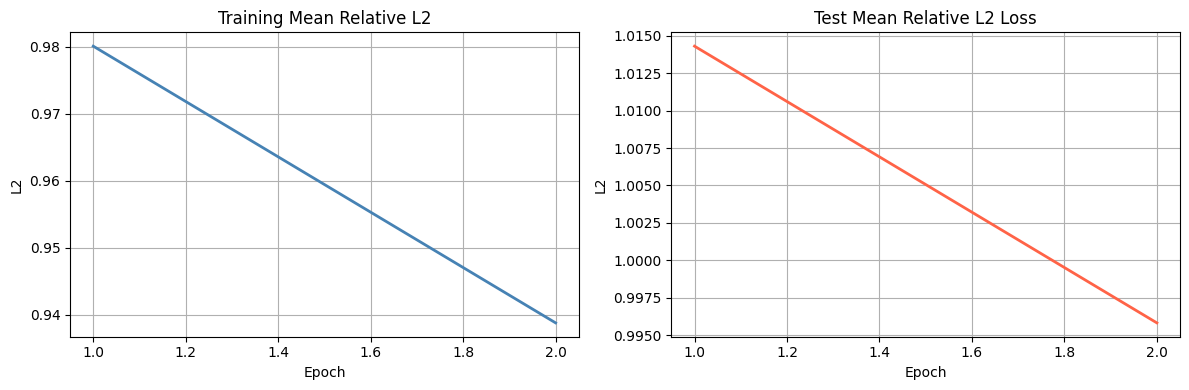

In [10]:
import os


epochs=2
epochs_range = range(1, epochs + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_range, train_mse_history, color='steelblue', linewidth=2)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("L2")
axes[0].set_title("Training Mean Relative L2")
axes[0].grid(True)

axes[1].plot(epochs_range, test_rel_l2_history, color='tomato', linewidth=2)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("L2")
axes[1].set_title("Test Mean Relative L2 Loss")
axes[1].grid(True)

plt.tight_layout()

plots_dir = "training_plots"
os.makedirs(plots_dir, exist_ok=True)
fig.savefig(os.path.join(plots_dir, "training_curves.png"), dpi=150, bbox_inches="tight")
print(f"Plot saved to {plots_dir}/training_curves.png")

plt.show()

# Inference

How does our network do on infering the propagation of the network?

In [15]:
# Load the model checkpoint (if applicable)

checkpoint = torch.load("trained_models_eigen/fno_eigen.pth")
fno = FNO2d(checkpoint["fno_architecture"], device=device)
fno.load_state_dict(checkpoint["model_state_dict"])

sample_index = 50
input_sample = x_test[sample_index, :, :, :].unsqueeze(0).to(device)

# Extract the propagated field distance for reference

output_dist = input_sample[0,0,0,0]
print(output_dist)

fno.eval()
with torch.no_grad():
    output_pred = fno(input_sample)

# Reconstruct field from real and imaginary components

output_pred = output_pred.squeeze(0).cpu().numpy()
output_field = output_pred[..., 0] + 1j*output_pred[..., 1]

tensor(0., device='cuda:0')


In [16]:
checkpoint["fno_architecture"]

{'modes1': 36,
 'modes2': 36,
 'width': 64,
 'n_layers': 1,
 'retrain_fno': 42,
 'input_chans': 6,
 'output_chans': 2}

Plot the input/output prediction

Plot saved to inference_plots/inference_sample90.png


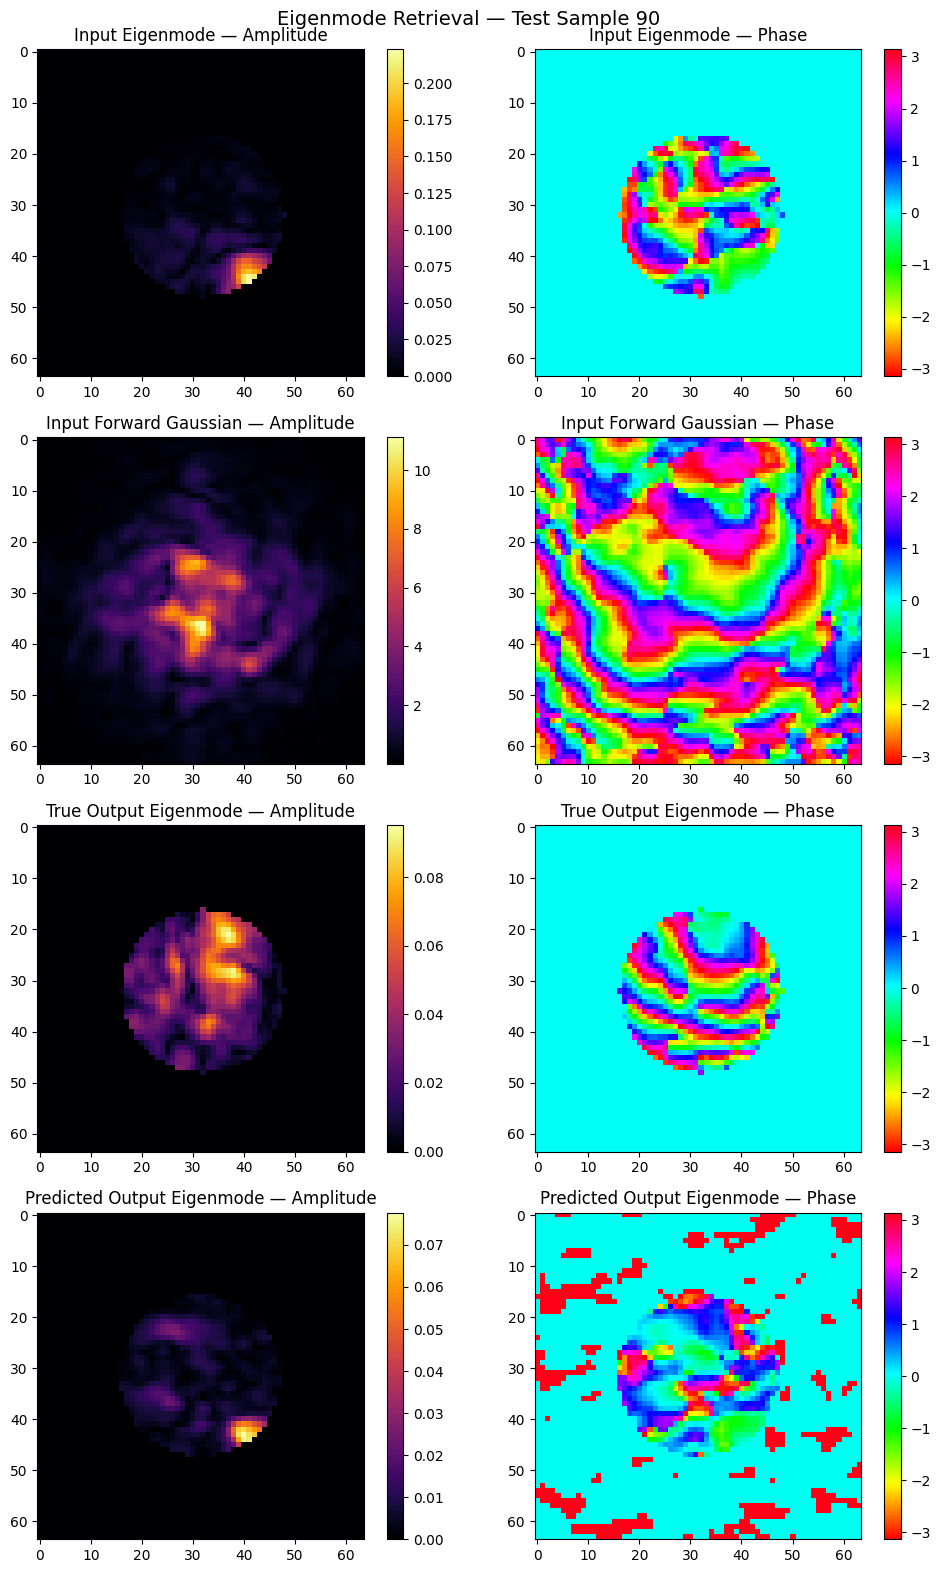

In [20]:
sample_index = 90
# --- Inference ---
input_sample = x_test[sample_index].unsqueeze(0).to(device)  # (1, H, W, 4)

fno.eval()
with torch.no_grad():
    output_pred = torch_circ_aperture(fno(input_sample), size=size, lensSize=lensSize)  # (1, H, W, 2)

# --- Extract fields from input ---
input_np = x_test[sample_index].cpu().numpy()          # (H, W, 4)
eigenmode_in  = input_np[..., 0] + 1j * input_np[..., 1]   # channels 0,1
gaussian_fwd  = input_np[..., 2] + 1j * input_np[..., 3]   # channels 2,3

# --- Ground truth output eigenmode ---
output_true_np = y_test[sample_index].cpu().numpy()    # (H, W, 2)
eigenmode_true = output_true_np[..., 0] + 1j * output_true_np[..., 1]

# --- Predicted output eigenmode ---
output_pred_np = output_pred.squeeze(0).cpu().numpy()  # (H, W, 2)
eigenmode_pred = output_pred_np[..., 0] + 1j * output_pred_np[..., 1]

# --- Plot ---
fig, axes = plt.subplots(4, 2, figsize=(10, 16))
fig.suptitle(f"Eigenmode Retrieval — Test Sample {sample_index}", fontsize=14)

rows = [
    (eigenmode_in,   "Input Eigenmode"),
    (gaussian_fwd,   "Input Forward Gaussian"),
    (eigenmode_true, "True Output Eigenmode"),
    (eigenmode_pred, "Predicted Output Eigenmode"),
]

for i, (field, title) in enumerate(rows):
    im_amp = axes[i, 0].imshow(np.abs(field), cmap='inferno')
    axes[i, 0].set_title(f"{title} — Amplitude")
    plt.colorbar(im_amp, ax=axes[i, 0])

    im_ph = axes[i, 1].imshow(np.angle(field), cmap='hsv')
    axes[i, 1].set_title(f"{title} — Phase")
    plt.colorbar(im_ph, ax=axes[i, 1])

plt.tight_layout()

plots_dir = "inference_plots"
os.makedirs(plots_dir, exist_ok=True)
fig.savefig(os.path.join(plots_dir, f"inference_sample{sample_index}.png"), dpi=150, bbox_inches="tight")
print(f"Plot saved to {plots_dir}/inference_sample{sample_index}.png")

plt.show()